In [ ]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
ROOTDIR = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/trends")

DATASETS = [
    "fhist",
    "goga2",
    "lens2",
]

VARIABLES = [
    "EFLX_LH_TOT",
    "FCTR",
    "FCEV",
    "FGEV",
    # "FSH",
    # "FSDS",
    # "FSDSC",
    "TLAI",
    "Q2M",
    "RH2M",
]

tndgc = {}
tndrg = {}
for ds in DATASETS:
    tndgc[ds] = {}
    tndrg[ds] = {}
    for v in VARIABLES:
        tndgc[ds][v] = xr.open_dataset(ROOTDIR / f"{ds.upper()}.{v}.year_dsc.ols_stats.195001-201412.nc")
        tndrg[ds][v] = xr.open_dataset(ROOTDIR / f"{ds.upper()}.{v}.year_dsc.giorgi_regions.ols_stats.195001-201412.nc")
        if ds == 'lens2':
            tndgc[ds][v] = tndgc[ds][v].assign_coords(member=np.arange(0, len(tndgc[ds][v].member)))
            tndrg[ds][v] = tndrg[ds][v].assign_coords(member=np.arange(0, len(tndrg[ds][v].member)))

In [ ]:
def plot_regional_trend_boxplot(v, sharey=True):
    fig, axes = plt.subplots(4, 6, figsize=(18, 12), layout='constrained', sharex=True, sharey=sharey)
    axs = axes.ravel()

    colors = ['tab:blue', 'indianred', 'tab:orange']

    for i, reg in enumerate(tndrg['fhist'][v].abbrev):
        bp = axs[i].boxplot(
            [
                tndrg['fhist'][v].slope.sel(abbrev=reg),
                tndrg['goga2'][v].slope.sel(abbrev=reg),
                tndrg['lens2'][v].slope.sel(abbrev=reg)
            ],
            patch_artist=True,
        )

        for box, color in zip(bp['boxes'], colors):
            box.set_facecolor(color)
            box.set_alpha(0.75)
        
        for median in bp['medians']:
            median.set_color('k')

        axs[i].set_xticks(np.arange(1, 4))
        axs[i].set_xticklabels(['FHIST', 'GOGA2', 'LENS2'])
        axs[i].set_title(reg['name'].values)
        axs[i].axhline(0, lw=0.8, c='k', zorder=0)

    for i in range(4):
        axs[i*6].set_ylabel(f"{v} [per year]")

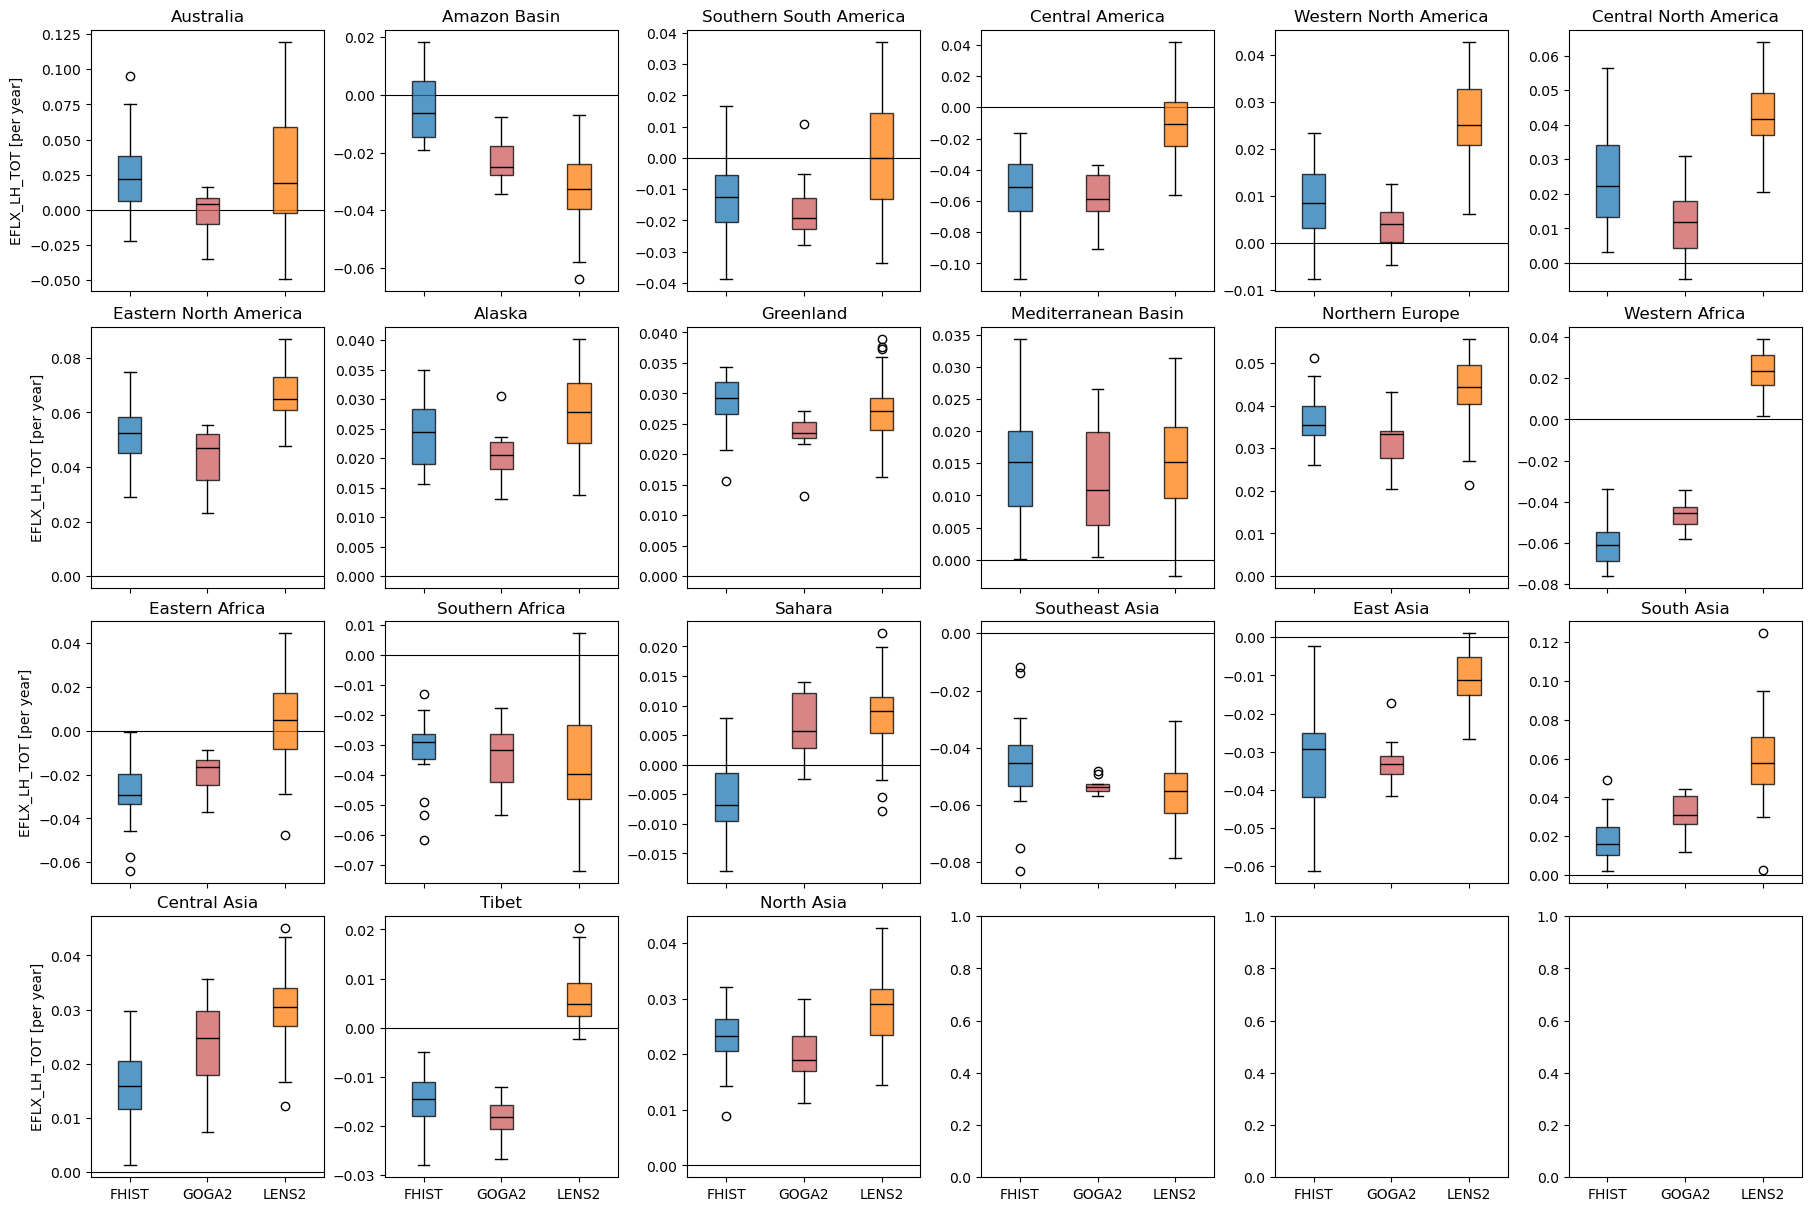

In [ ]:
plot_regional_trend_boxplot('EFLX_LH_TOT', False)

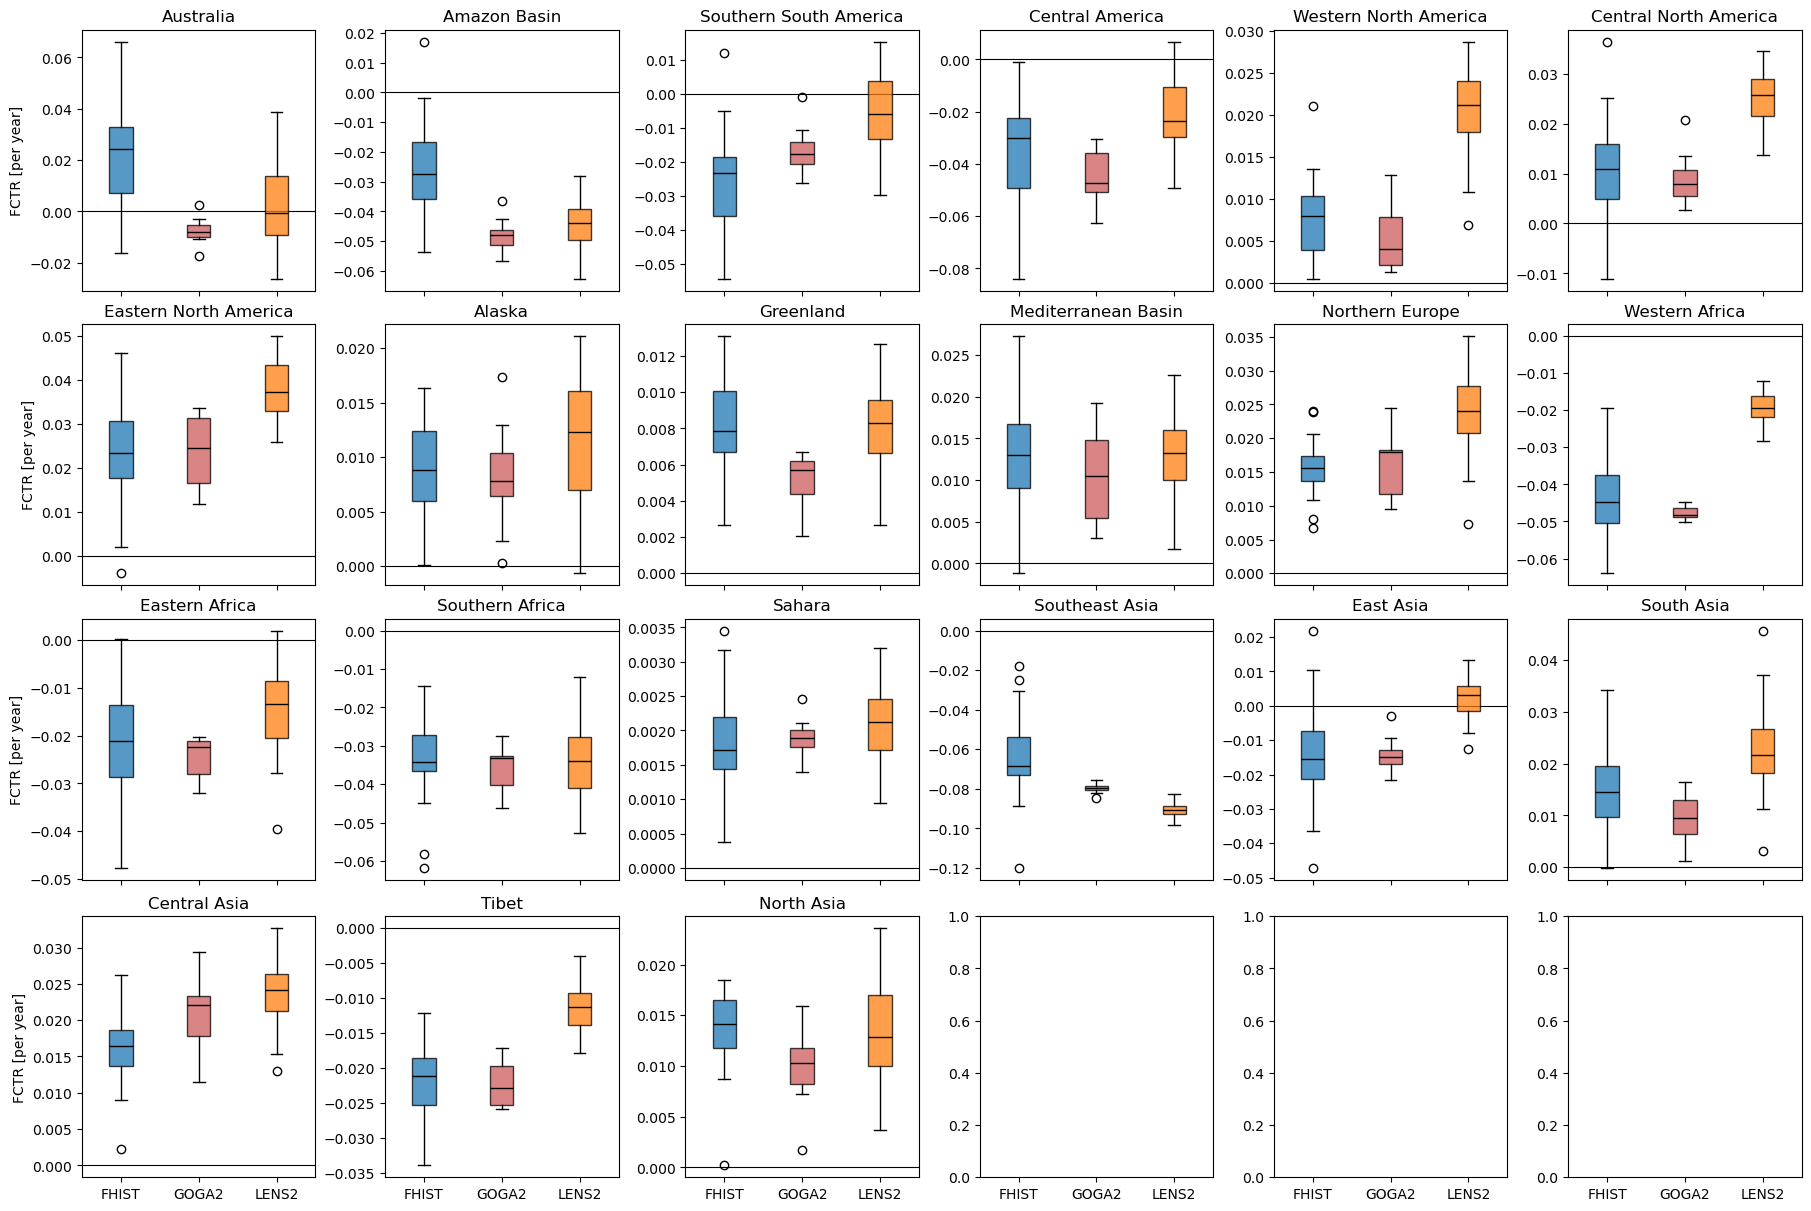

In [ ]:
plot_regional_trend_boxplot('FCTR', False)

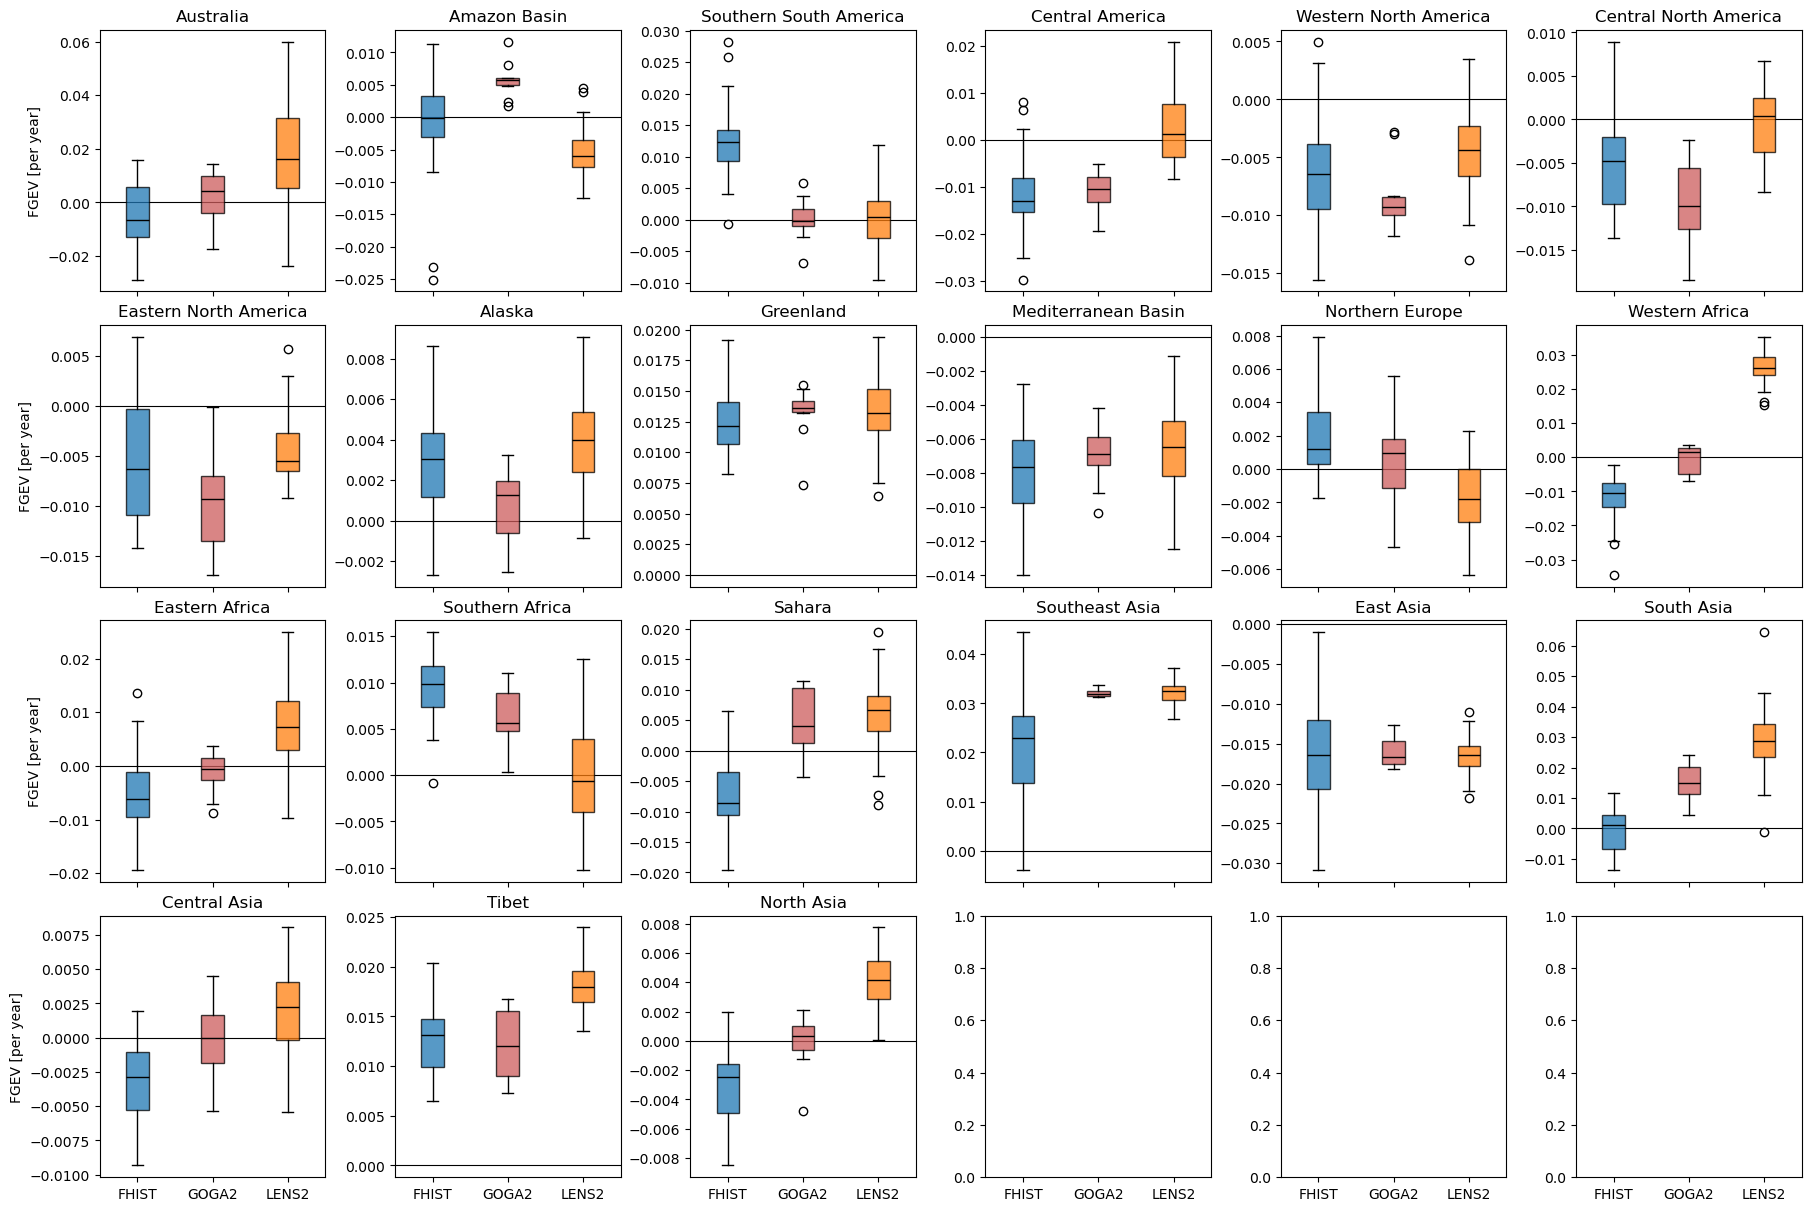

In [ ]:
plot_regional_trend_boxplot('FGEV', False)

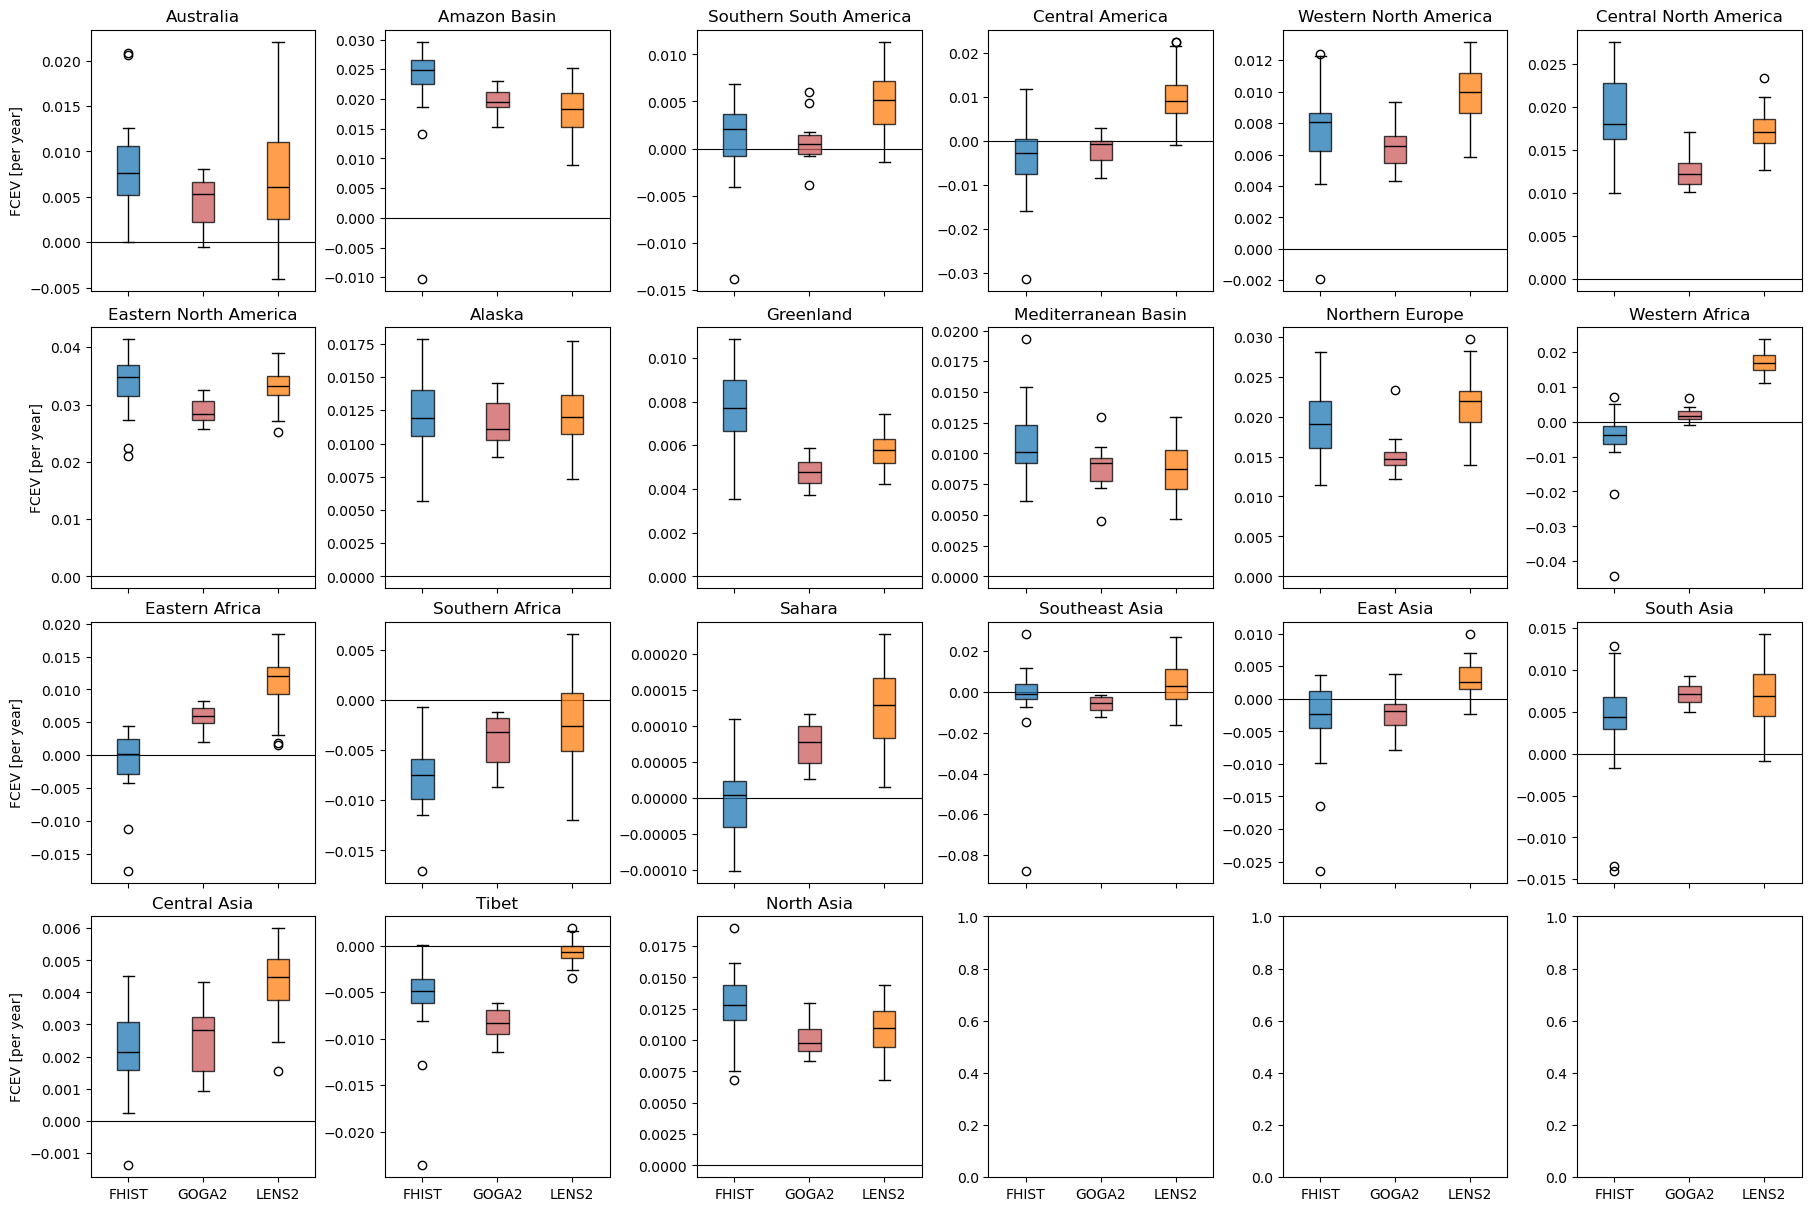

In [ ]:
plot_regional_trend_boxplot('FCEV', sharey=False)

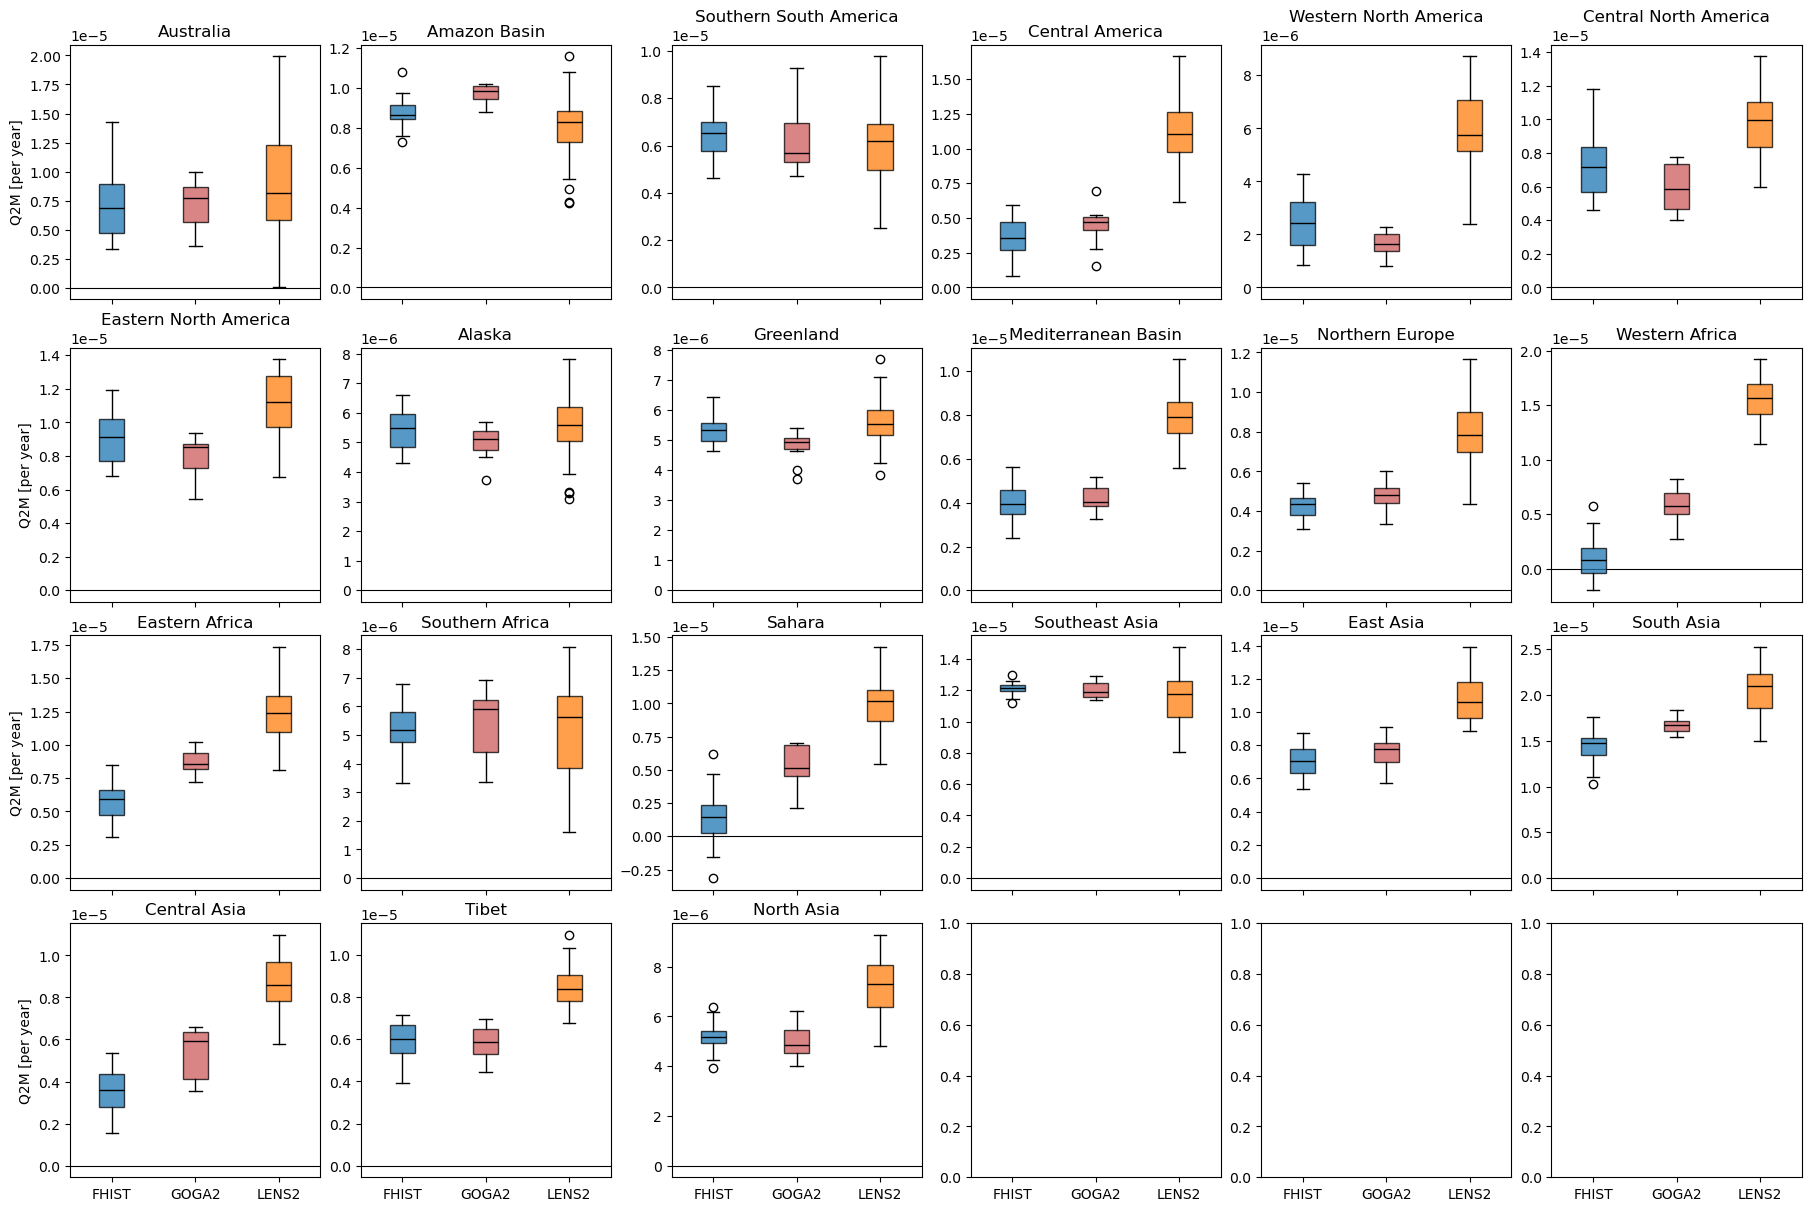

In [ ]:
plot_regional_trend_boxplot('Q2M', False)

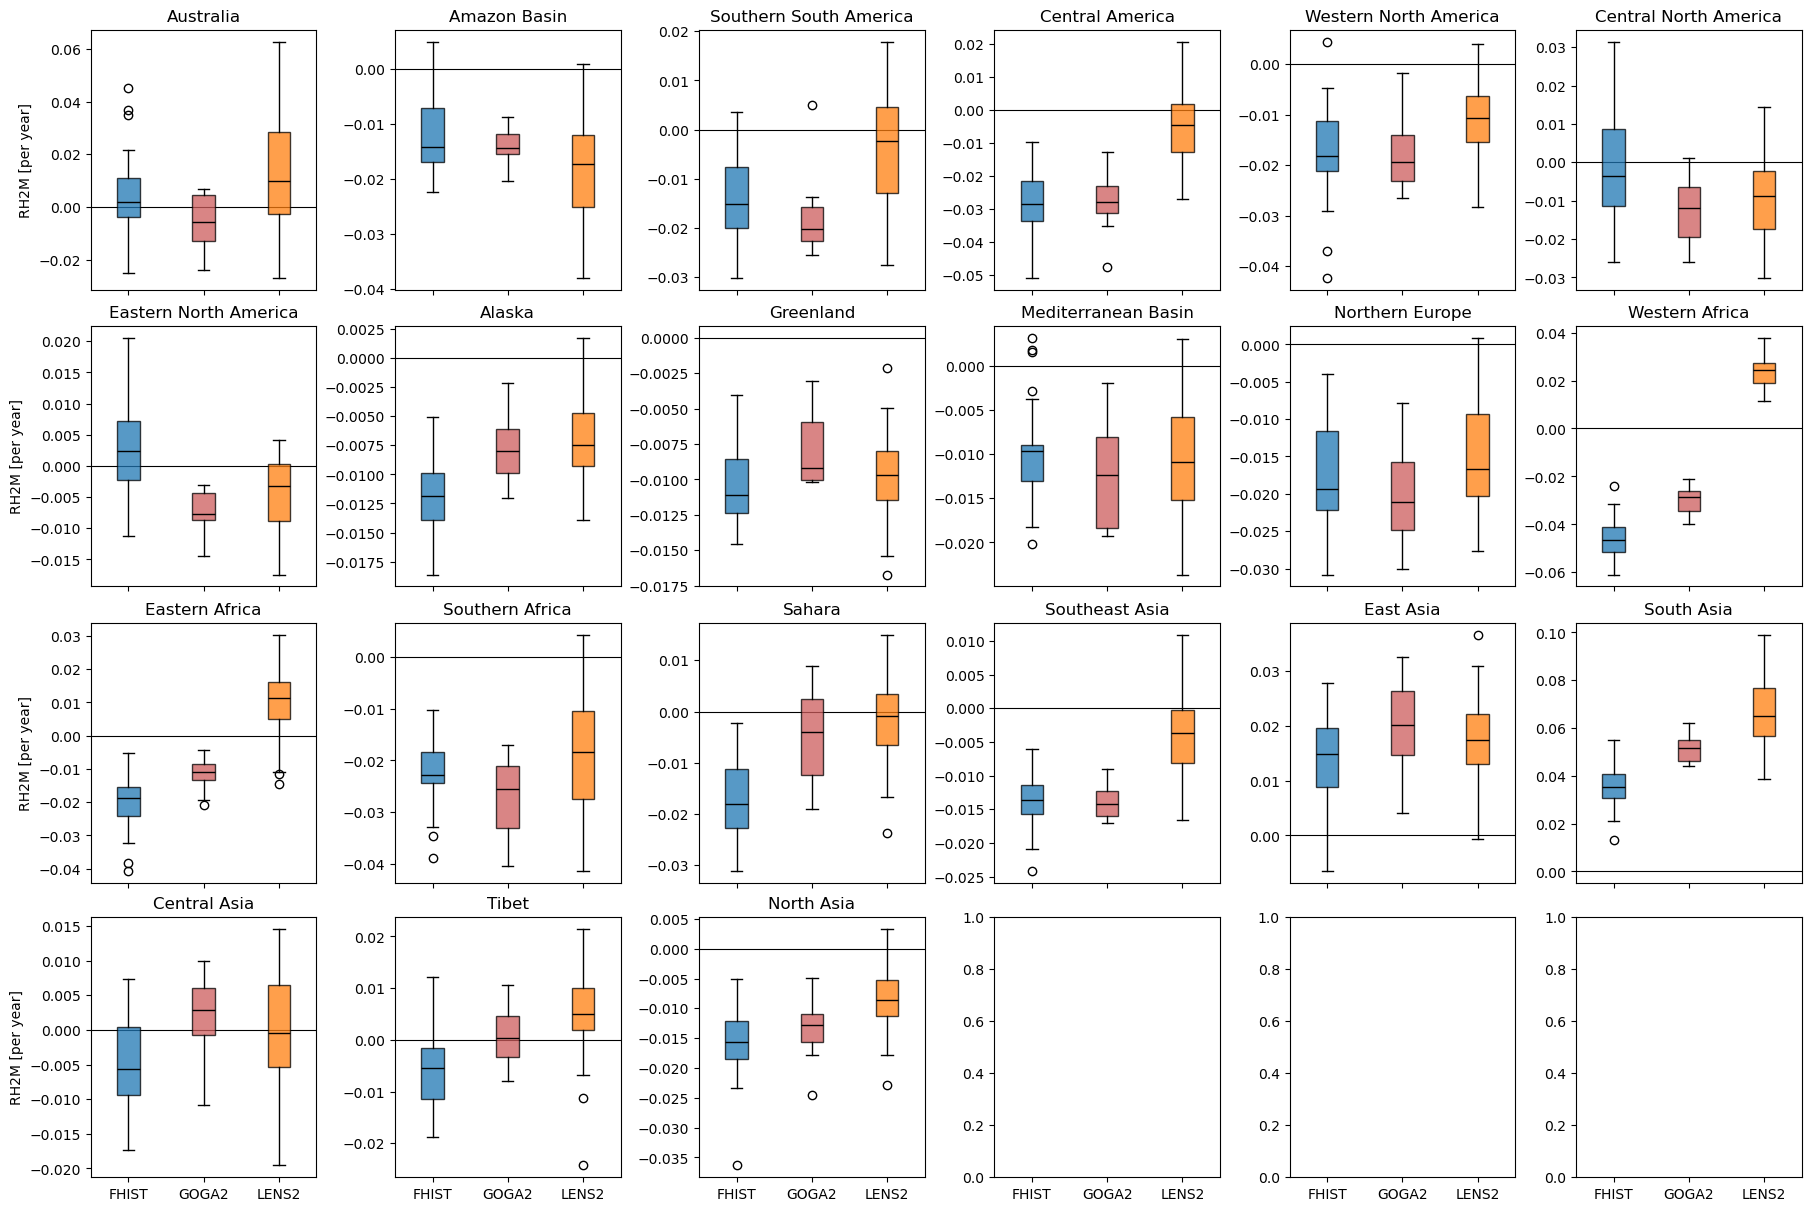

In [ ]:
plot_regional_trend_boxplot('RH2M', False)

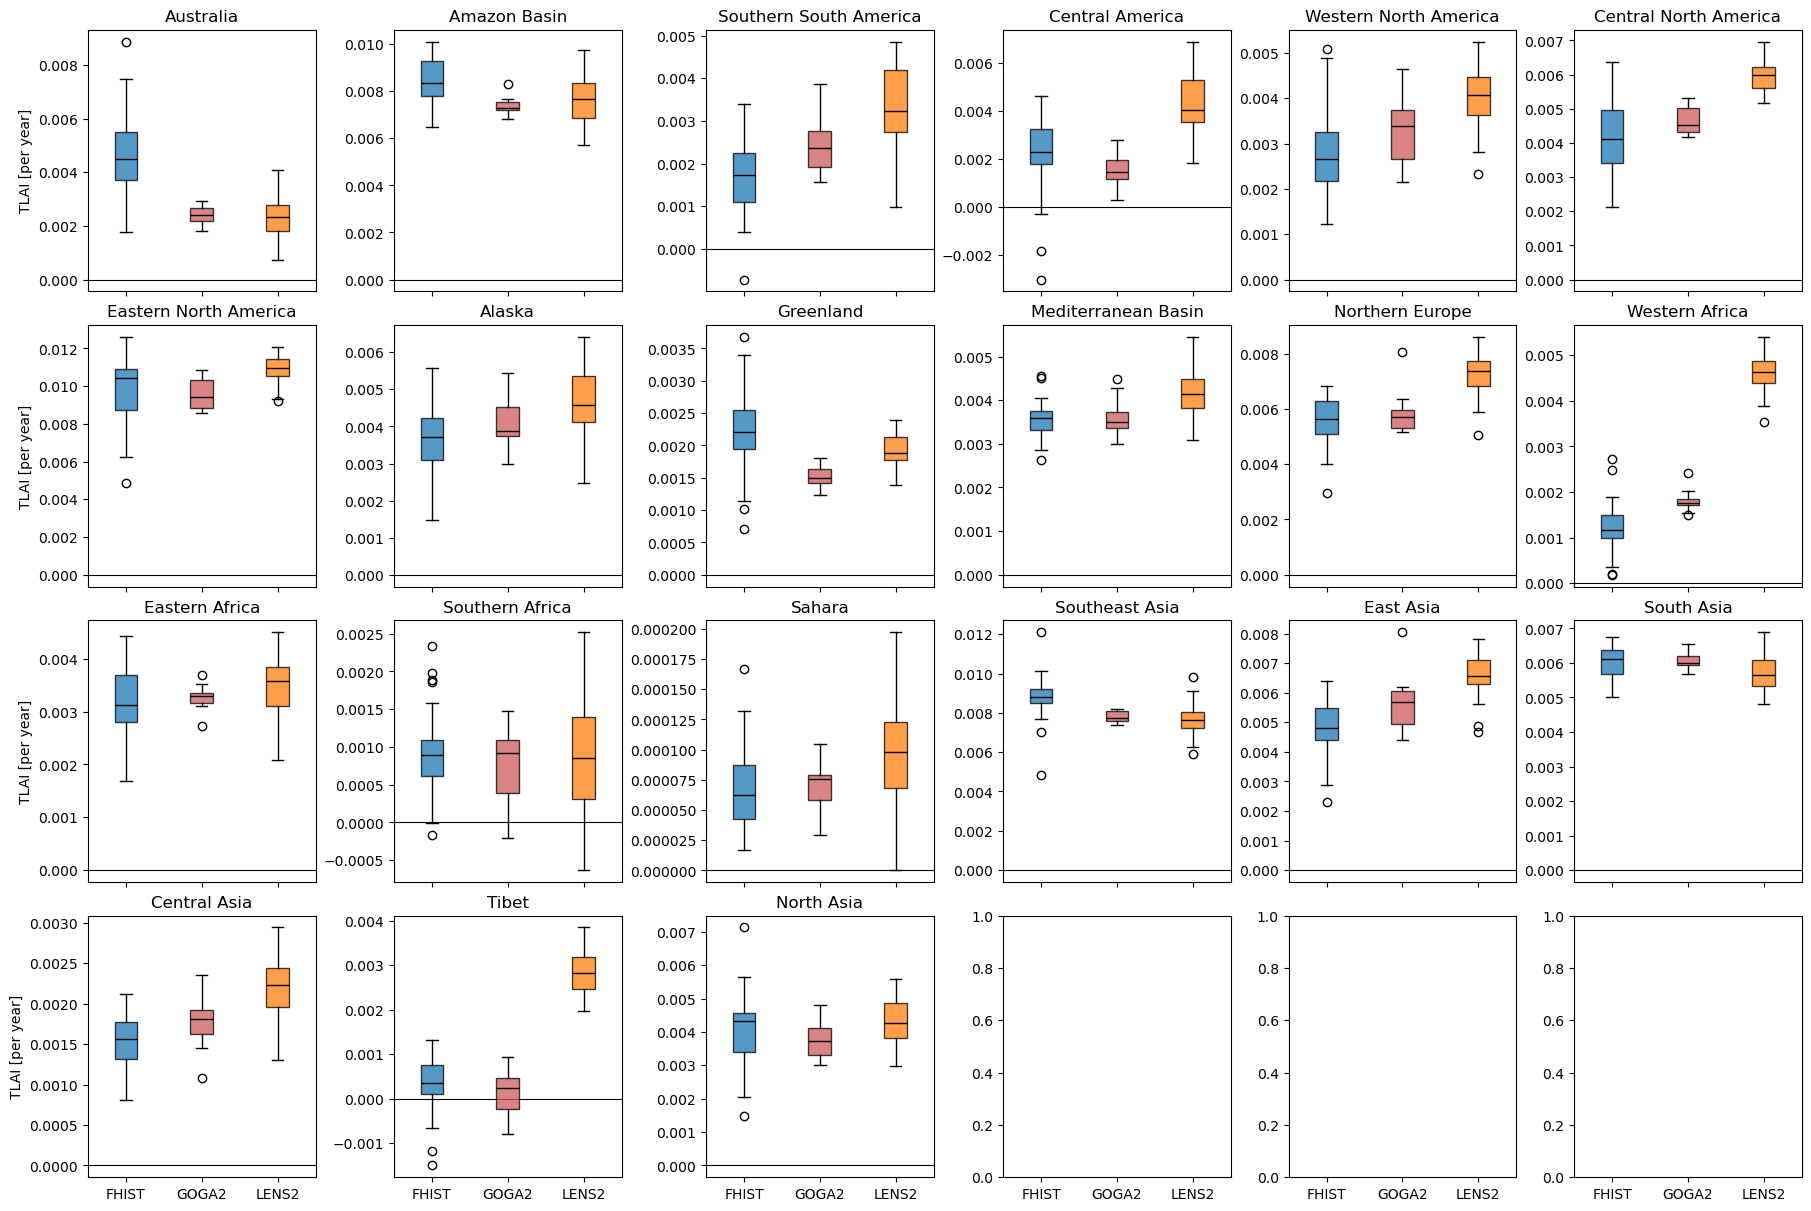

In [ ]:
plot_regional_trend_boxplot('TLAI', False)

In [ ]:
gc = dict(lat=45, lon=270, method='nearest')

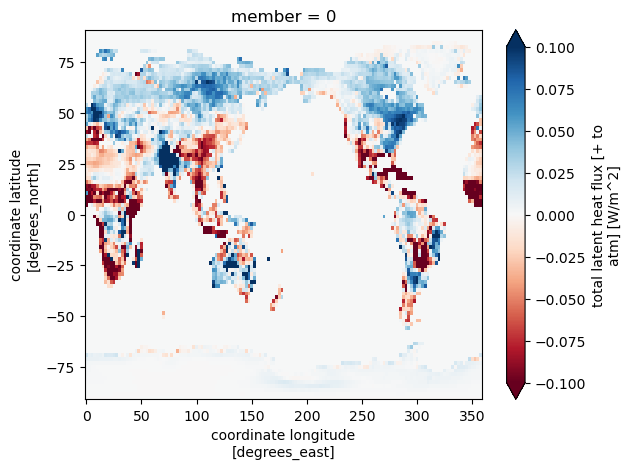

In [ ]:
tndgc['fhist']['EFLX_LH_TOT'].slope.isel(member=0).plot(vmin=-0.1, vmax=0.1, cmap='RdBu')

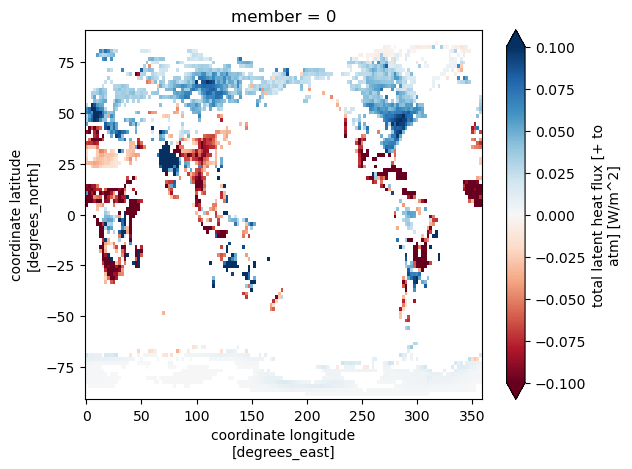

In [ ]:
(
    tndgc['fhist']['EFLX_LH_TOT'].slope
    .isel(member=0)
    .where(tndgc['fhist']['EFLX_LH_TOT'].p_value.isel(member=0) < 0.05)
    .plot(vmin=-0.1, vmax=0.1, cmap='RdBu')
)

(array([1., 0., 1., 2., 7., 3., 6., 4., 1., 2.]),
 array([-0.06589899, -0.05088559, -0.0358722 , -0.0208588 , -0.0058454 ,
         0.00916799,  0.02418139,  0.03919479,  0.05420818,  0.06922158,
         0.08423498]),
 <BarContainer object of 10 artists>)

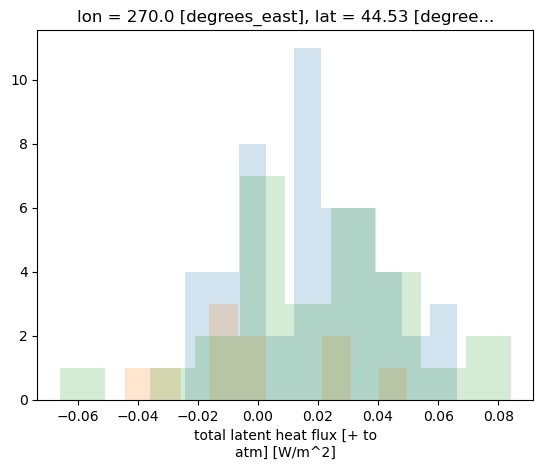

In [ ]:
tndgc['lens2']['EFLX_LH_TOT'].slope.sel(**gc).plot.hist(alpha=0.2)
tndgc['goga2']['EFLX_LH_TOT'].slope.sel(**gc).plot.hist(alpha=0.2)
tndgc['fhist']['EFLX_LH_TOT'].slope.sel(**gc).plot.hist(alpha=0.2)

In [ ]:
(
    trend['fhist']['FCTR']['year'].slope
    .where(
        abs(trend['fhist']['FCTR']['year'].slope) > 

In [ ]:
plt.boxplot(
    x=[
        trend['fhist']['FCTR'].slope.sel(**gc),
        trend['goga2']['FCTR'].slope.sel(**gc),
        trend['lens2']['FCTR'].slope.sel(**gc),
    ],
    label=[
        "FHIST",
        "GOGA2",
        "LENS2",
    ]
);
plt.axhline(0, lw=0.8, c='k')

NameError: name 'gc' is not defined

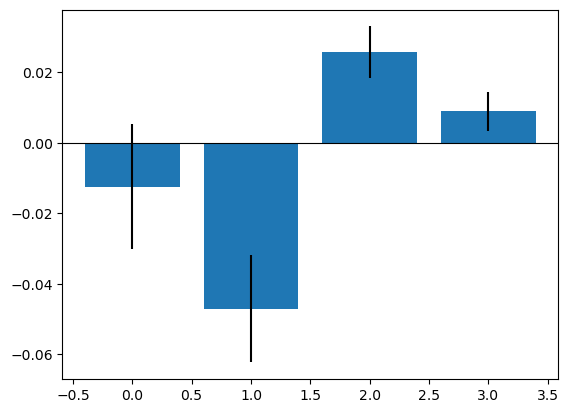

In [ ]:
m = 0

plt.bar(
    x=np.arange(4),
    height=[
        trend['fhist']['EFLX_LH_TOT']['year'].slope.sel(**gc, member=m),
        trend['fhist']['FCTR']['year'].slope.sel(**gc, member=m),
        trend['fhist']['FGEV']['year'].slope.sel(**gc, member=m),
        trend['fhist']['FCEV']['year'].slope.sel(**gc, member=m),
    ],
    yerr=[
        trend['fhist']['EFLX_LH_TOT']['year'].slope_stderr.sel(**gc, member=m),
        trend['fhist']['FCTR']['year'].slope_stderr.sel(**gc, member=m),
        trend['fhist']['FGEV']['year'].slope_stderr.sel(**gc, member=m),
        trend['fhist']['FCEV']['year'].slope_stderr.sel(**gc, member=m),
    ],
)

plt.axhline(0, lw=0.8, c='k')

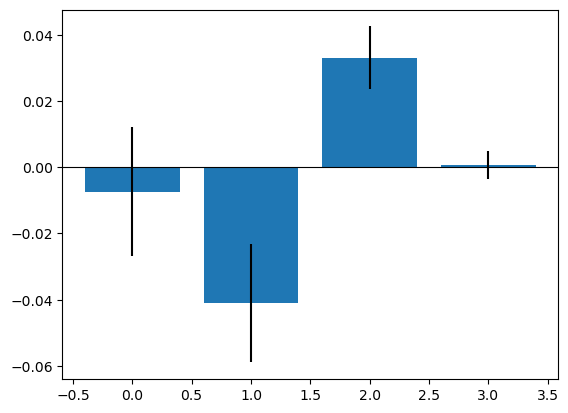

In [ ]:
m = 0

plt.bar(
    x=np.arange(4),
    height=[
        trend['goga2']['EFLX_LH_TOT']['year'].slope.sel(**gc, member=m),
        trend['goga2']['FCTR']['year'].slope.sel(**gc, member=m),
        trend['goga2']['FGEV']['year'].slope.sel(**gc, member=m),
        trend['goga2']['FCEV']['year'].slope.sel(**gc, member=m),
    ],
    yerr=[
        trend['goga2']['EFLX_LH_TOT']['year'].slope_stderr.sel(**gc, member=m),
        trend['goga2']['FCTR']['year'].slope_stderr.sel(**gc, member=m),
        trend['goga2']['FGEV']['year'].slope_stderr.sel(**gc, member=m),
        trend['goga2']['FCEV']['year'].slope_stderr.sel(**gc, member=m),
    ],
)

plt.axhline(0, lw=0.8, c='k')

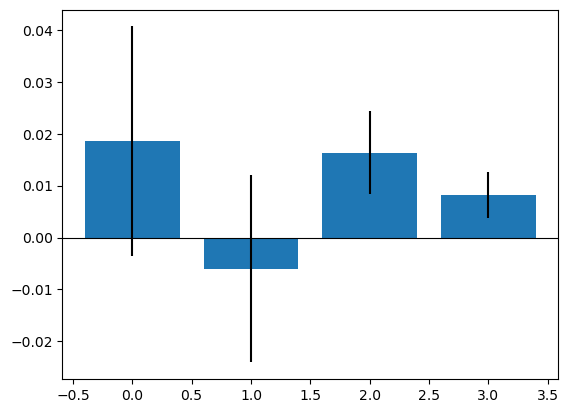

In [ ]:
m = 0

plt.bar(
    x=np.arange(4),
    height=[
        trend['lens2']['EFLX_LH_TOT']['year'].slope.sel(**gc, member=m),
        trend['lens2']['FCTR']['year'].slope.sel(**gc, member=m),
        trend['lens2']['FGEV']['year'].slope.sel(**gc, member=m),
        trend['lens2']['FCEV']['year'].slope.sel(**gc, member=m),
    ],
    yerr=[
        trend['lens2']['EFLX_LH_TOT']['year'].slope_stderr.sel(**gc, member=m),
        trend['lens2']['FCTR']['year'].slope_stderr.sel(**gc, member=m),
        trend['lens2']['FGEV']['year'].slope_stderr.sel(**gc, member=m),
        trend['lens2']['FCEV']['year'].slope_stderr.sel(**gc, member=m),
    ],
)

plt.axhline(0, lw=0.8, c='k')

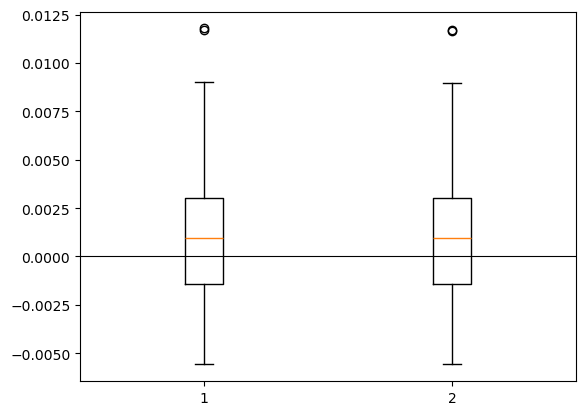

In [ ]:
plt.boxplot(
    x=[
        trend['fhist']['TLAI']['year'].slope.sel(**gc),
        trend['fhist']['TLAI']['month'].slope.sel(**gc),
    ],
);
plt.axhline(0, lw=0.8, c='k')

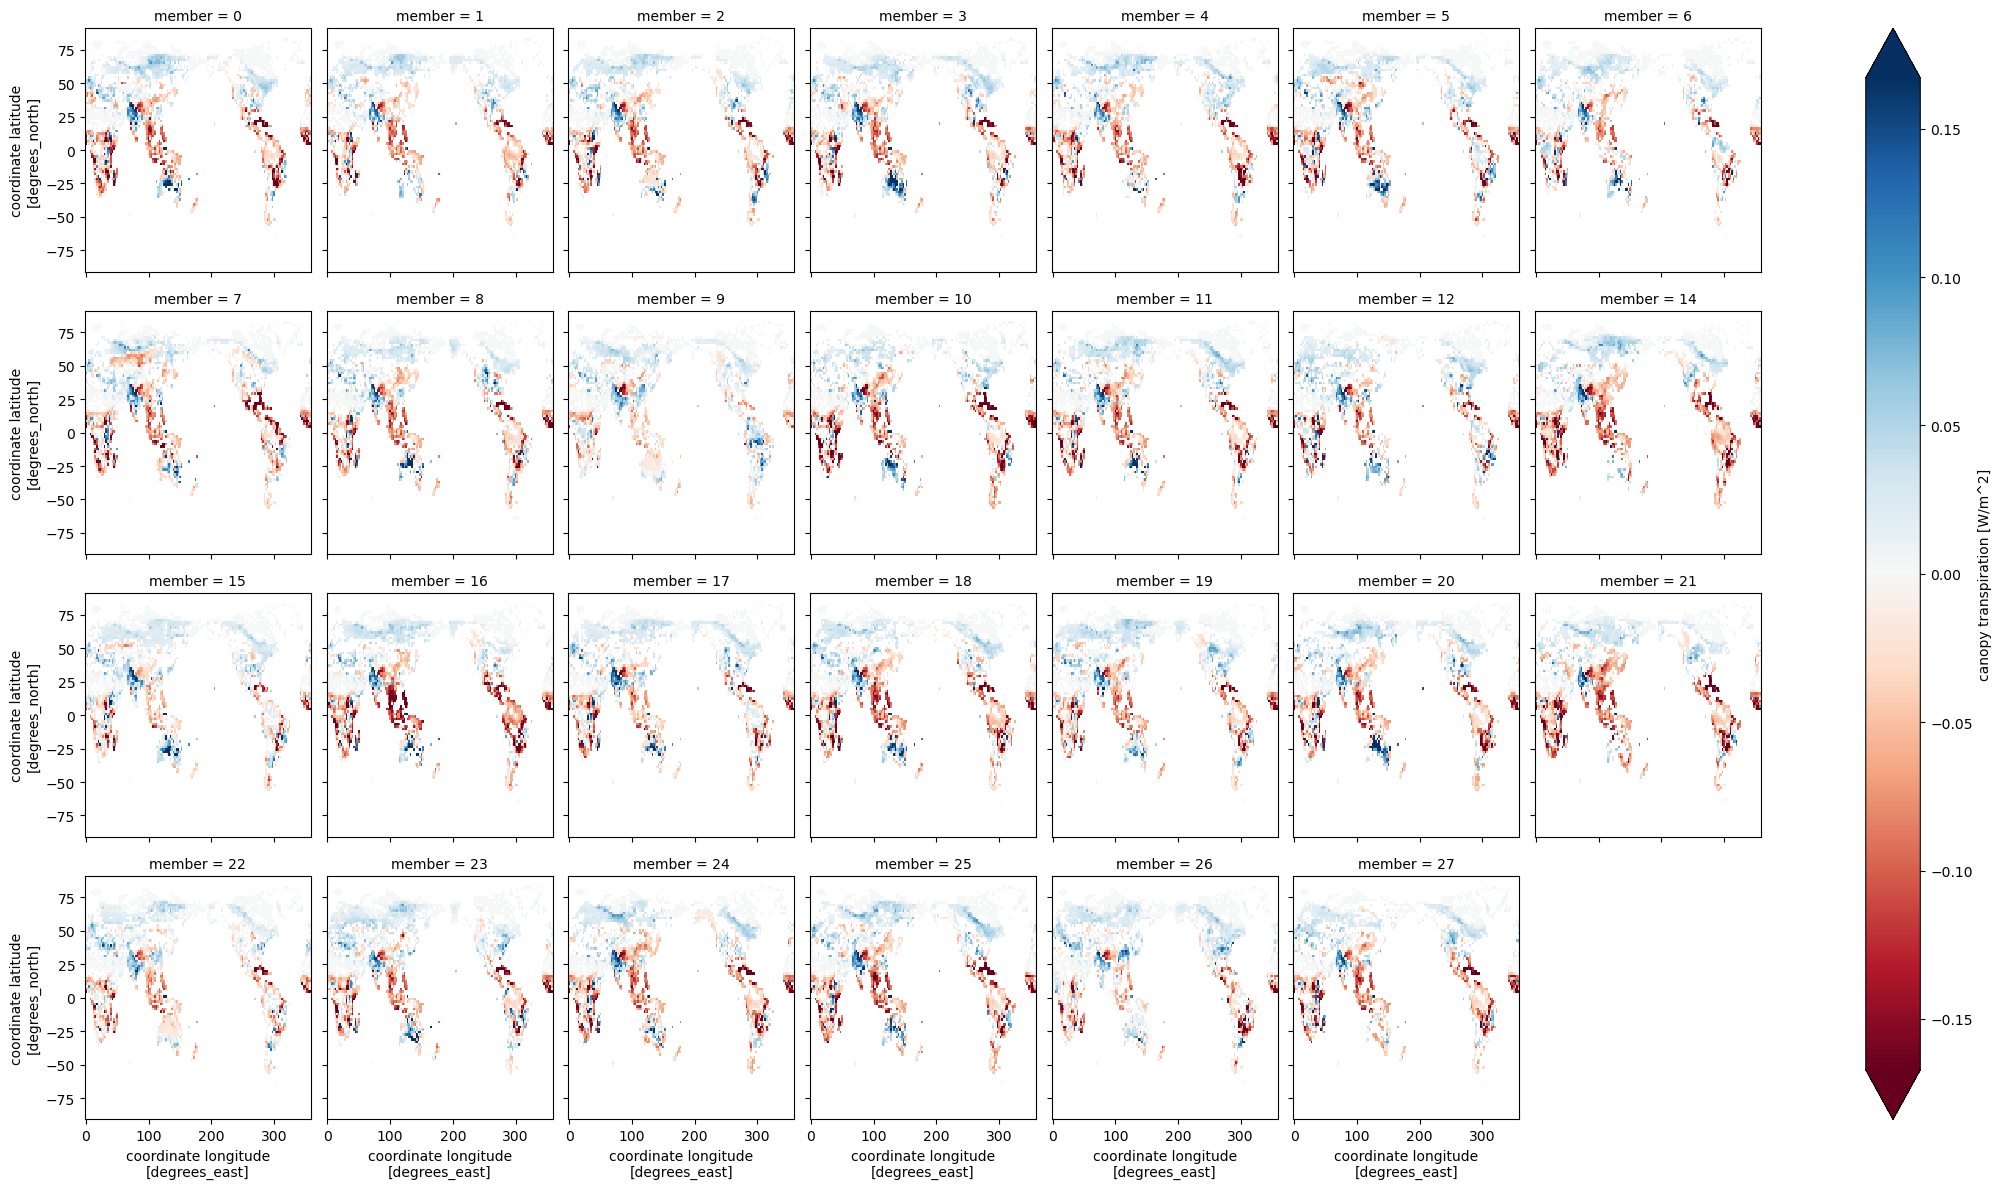

In [ ]:

trend['FCTR']['month'].slope.where(trend['FCTR']['month'].p_value < 0.05).plot(col='member', col_wrap=7, robust=True, cmap='RdBu')